In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('../data/customers.csv')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 27.8 KB


In [5]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [6]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [10]:
df.groupby('Customer ID')['Total Spend'].sum().sort_values(ascending=False).head(10)

Customer ID
110    1520.1
218    1500.1
188    1500.1
260    1500.1
290    1500.1
158    1500.1
331    1500.1
128    1500.1
146    1490.1
206    1490.1
Name: Total Spend, dtype: float64

In [11]:
df.groupby('City')['Total Spend'].sum().sort_values(ascending=False)

City
San Francisco    84666.8
New York         68737.1
Los Angeles      47524.0
Miami            40042.6
Chicago          28993.2
Houston          25919.9
Name: Total Spend, dtype: float64

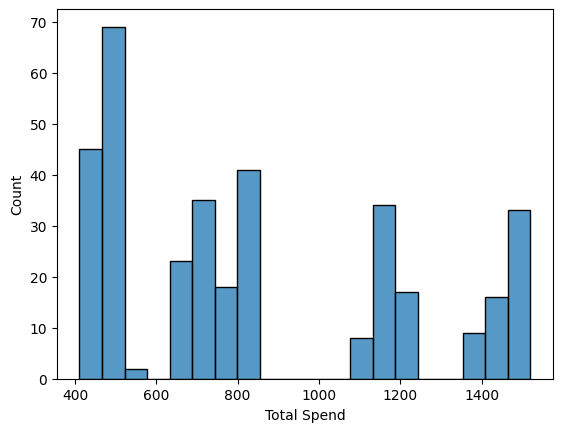

In [12]:
sns.histplot(df['Total Spend'], bins=20)
plt.show()

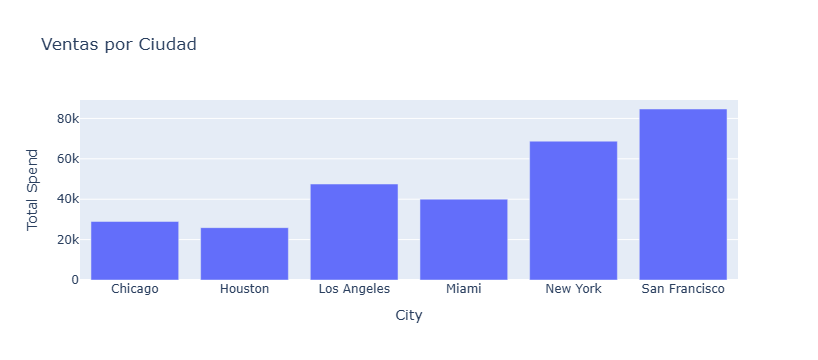

In [11]:
import plotly.express as px

fig = px.bar(df.groupby('City')['Total Spend'].sum().reset_index(),
             x='City', y='Total Spend', title='Ventas por Ciudad')

fig.show()

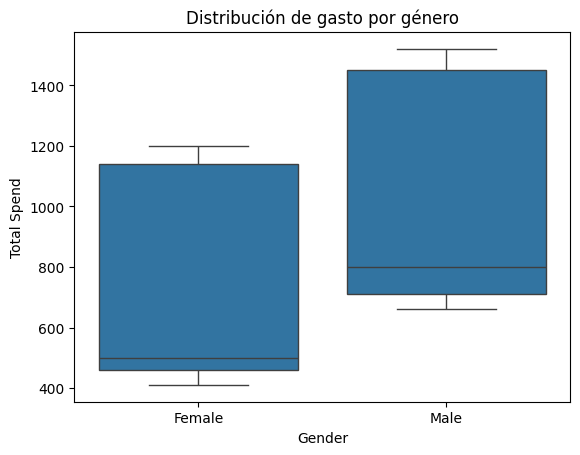

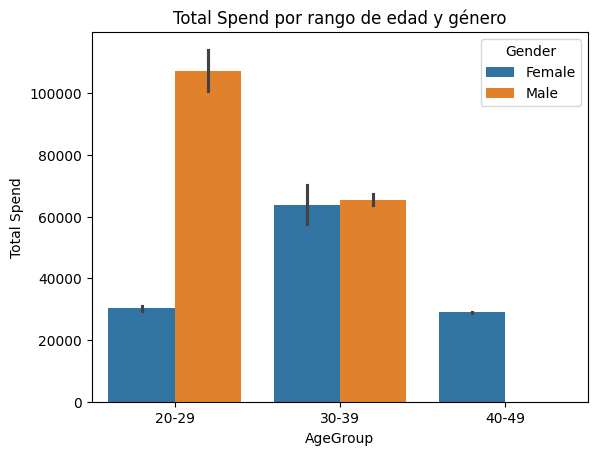

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribución de gasto por género
sns.boxplot(x='Gender', y='Total Spend', data=df)
plt.title("Distribución de gasto por género")
plt.show()

# Distribución de gasto por rangos de edad
df['AgeGroup'] = pd.cut(df['Age'], bins=[20,30,40,50], labels=['20-29','30-39','40-49'])
sns.barplot(x='AgeGroup', y='Total Spend', hue='Gender', data=df, estimator=sum)
plt.title("Total Spend por rango de edad y género")
plt.show()


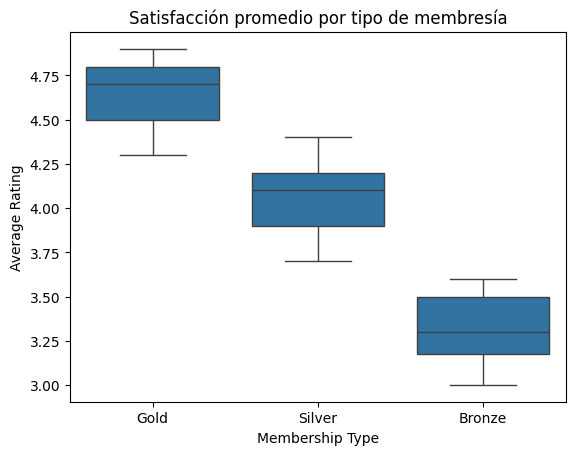

Membership Type  Satisfaction Level
Bronze           Unsatisfied           0.508772
                 Neutral               0.491228
Gold             Satisfied             1.000000
Silver           Unsatisfied           0.495726
                 Neutral               0.435897
                 Satisfied             0.068376
Name: proportion, dtype: float64

In [13]:
sns.boxplot(x='Membership Type', y='Average Rating', data=df)
plt.title("Satisfacción promedio por tipo de membresía")
plt.show()

df.groupby('Membership Type')['Satisfaction Level'].value_counts(normalize=True)


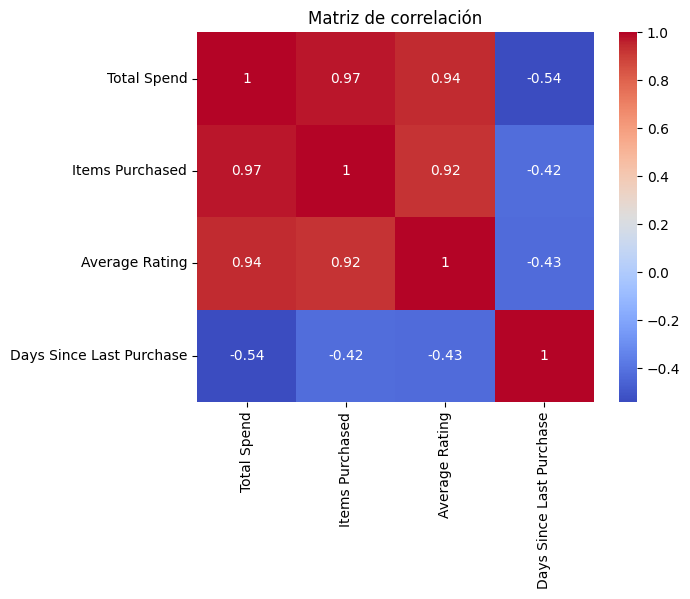

In [14]:
import numpy as np

corr = df[['Total Spend','Items Purchased','Average Rating','Days Since Last Purchase']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


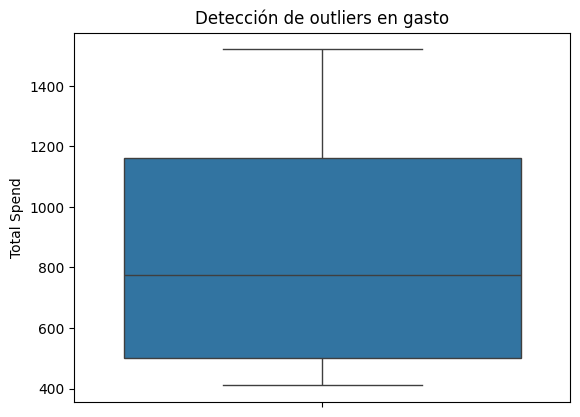

,Customer ID,City,Total Spend
9,110,San Francisco,1520.1
27,128,San Francisco,1500.1
57,158,San Francisco,1500.1
87,188,San Francisco,1500.1
117,218,San Francisco,1500.1
159,260,San Francisco,1500.1
189,290,San Francisco,1500.1
230,331,San Francisco,1500.1


In [15]:
sns.boxplot(y=df['Total Spend'])
plt.title("Detección de outliers en gasto")
plt.show()

# Clientes con gasto anómalo
outliers = df[df['Total Spend'] > df['Total Spend'].quantile(0.95)]
outliers[['Customer ID','City','Total Spend']]


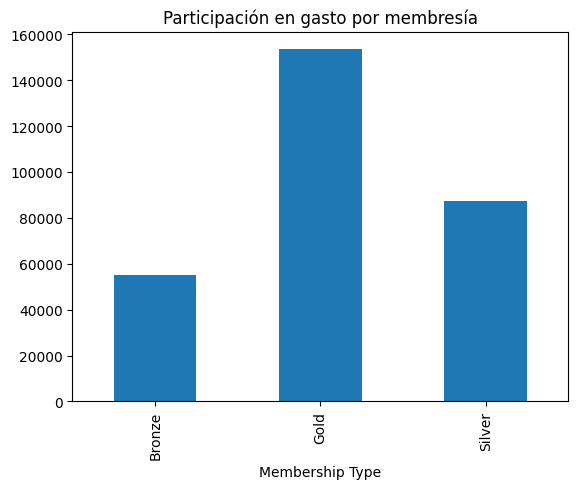

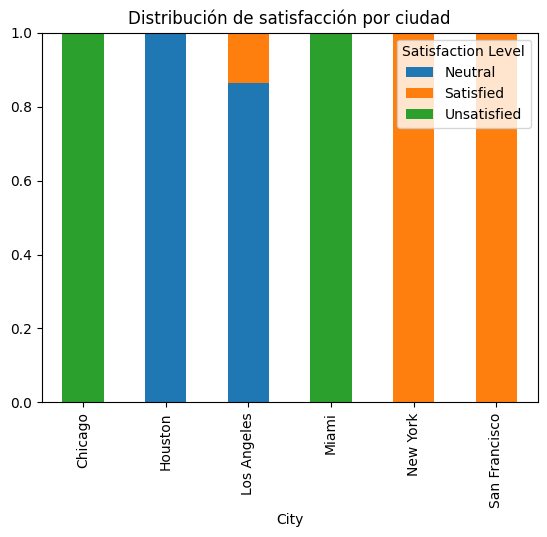

In [16]:
df.groupby('Membership Type')['Total Spend'].sum().plot(kind='bar')
plt.title("Participación en gasto por membresía")
plt.show()

df.groupby('City')['Satisfaction Level'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True)
plt.title("Distribución de satisfacción por ciudad")
plt.show()
